### np.where
Often we are presented with a data set which is made up of background and signal.
Take the data here;

In [ ]:
import numpy as np
import matplotlib.pyplot as plt  # This will be covered in next week's lectures
myData = np.load(('../Course-Data/Week 1/testData.npy'))

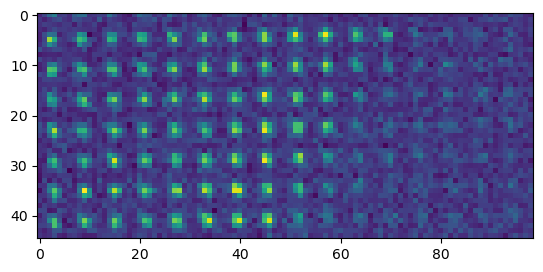

In [ ]:
plt.imshow(myData[:,:,0]) # this shows us the first frame in the data set

These are molecules on a substrate, you can see that there are some regions without molecules and there is space between them.  This data was taken over time, so we have ploted the first frame of a video.
What I want to do is see how the molecules change over time. First, let us find the brighest molecule.

In [ ]:
# This line is quite complicated so we will break it down
positions = np.where(myData[:,:,0] == np.max(myData[:,:,0]))

The line above uses the np.where command, this command takes a conditional statment and returns the position(s) in the numpy array where that condition is true. The condition is defined as;
<br>
myData[:,:,0] == np.max(myData[:,:,0])
<br>
This is saying give me all the positions where "myData[:,:,0]" this is the first frame of our data, is equal to (== means equal to) the maximum value of the first frame.


In [ ]:
print(positions)

(array([35]), array([9]))


Notice how np.where reports the positions
(array([35]), array([9])), it's a tuple where the first entry is a list of all the X coordinates which corrispond to a true condition and the second array contains the corrisponding Y coordinates.

<class 'tuple'>


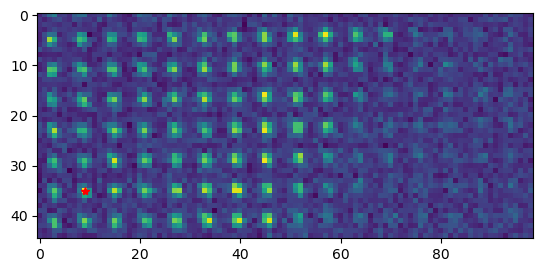

In [ ]:
plt.imshow(myData[:,:,0])
plt.plot(positions[1][0],positions[0][0],'r*') #Annoyingly np.where returns a tuple

Ok, there is my brightest molecule. I now want to plot its intensity over time.

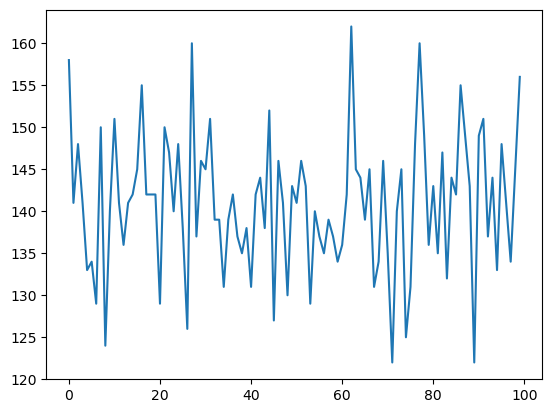

In [ ]:
# This plots the single brighest pixel
Xpos = positions[1][0] # My X position is the second entry in the first array
Ypos = positions[0][0] # My X position is the first entry in the first array
# remember that myData is a 3D array, X,Y and time, it is a movie.
# So I can plot a single frame (a point in time) as we have done above or I can trace a single pixel through time as I do below.
temp = myData[Xpos,Ypos,:]
plt.plot(temp)

(3, 3, 100)


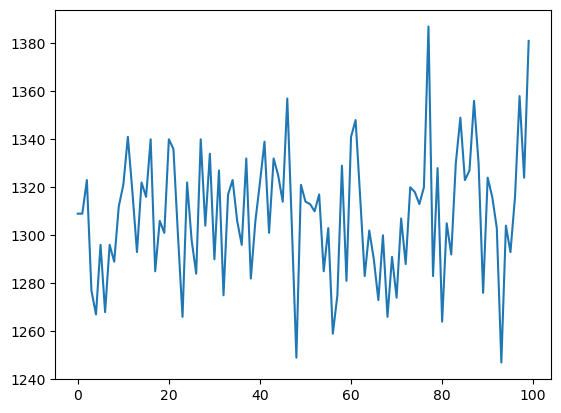

In [ ]:
# However, my molecule extends spatially over a number of pixels, so let us collect those
extent = 1  # This is the size of the block I am going to cut out
MiniArray = myData[Xpos-extent:Xpos+extent+1, Ypos-extent:Ypos+extent+1,:]
# The line above might look complicated, but it is really just slicing an array
print(MiniArray.shape)  # I now have a 100 by (2 x extent) +1 by (2 x extent) + 1 array
# With the 100 coming from the number of frames in the data set
moleculeData = np.sum(MiniArray, axis=0) # I sum the 100 subframes in X
moleculeData = np.sum(moleculeData, axis=0) # I sum the 100 subframes in Y
plt.plot(moleculeData)

(0.0, 80.0, 2300.0, 2500.0)

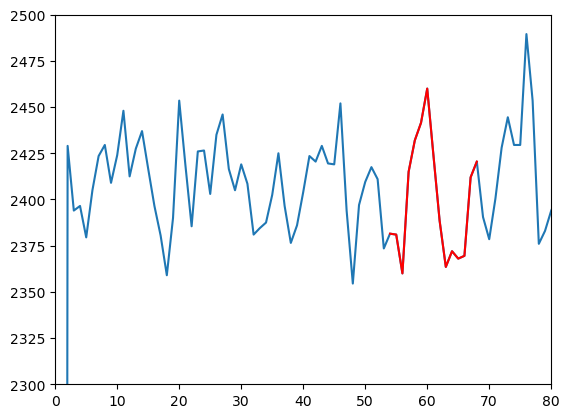

In [ ]:
# We can build a crude smoothing algo to clean this up a litte
# The highlight red region is the single molecule blinking
step = 3
smoothMolecule = np.zeros(np.shape(moleculeData)[0]-2 * step)
for I in range(step,np.shape(moleculeData)[0]- 2 * step):
    smoothMolecule[I] = np.mean(moleculeData[I-1:I+1])
plt.plot(smoothMolecule[1:]-np.min(smoothMolecule[1:]))
plt.plot(np.arange(54,69,1),smoothMolecule[55:70]-np.min(smoothMolecule[1:]), 'r')
plt.axis((0,80,2300,2500))

array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69])